# Sinusoid Regression: Kron Last Layer (Laplace) vs Bayesian-Torch BNNs

Head-to-head comparison on a larger sinusoid dataset (600 / 200 / 200 / 200 train-val-testID-testOOD).
Laplace side: `kron / last_layer` with `marglik` and `gridsearch` tuning.
BNN side: Flipout and BBB (Reparameterization) × scratch and MOPED initialization.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, regression_uncertainty_stats,
                    load_sinusoid)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 711
sigma_noise = 0.3
num_mc_samples = 100
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_comparison_1seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"Checkpoint dir: {CHECKPOINT_BASE}")

Device: cuda
Checkpoint dir: /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_comparison_1seed


In [2]:
# Dataset: 1000 pts total — 60/20/20 ID split + equal-size OOD test
data = load_sinusoid(
    n_data=600, sigma_noise=sigma_noise, batch_size=64, seed=SEED, device=device,
    n_val=200, n_test_id=200, n_test_ood=200,
)
X_train, y_train = data["X_train"], data["y_train"]
train_loader     = data["train_loader"]
X_val, y_val     = data["X_val"], data["y_val"]
val_loader       = data["val_loader"]
X_test_id,  y_test_id  = data["X_test_id"],  data["y_test_id"]
X_test_ood, y_test_ood = data["X_test_ood"], data["y_test_ood"]
X_train_np    = X_train.flatten().numpy()
y_train_np    = y_train.flatten().numpy()
y_val_np      = y_val.flatten().numpy()
y_test_id_np  = y_test_id.flatten().numpy()
y_test_ood_np = y_test_ood.flatten().numpy()
X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)
x_grid = X_test_grid.flatten().numpy()

print(f"Train: {len(X_train)}, Val: {len(X_val)}, "
      f"Test ID: {len(X_test_id)}, Test OOD: {len(X_test_ood)}")

Train: 600, Val: 200, Test ID: 200, Test OOD: 200


In [3]:
def get_model():
    seed_everything(SEED)
    return nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50, 1))

def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax):
    epi = np.asarray(epistemic_std).ravel()
    total = np.sqrt(epi**2 + float(aleatoric_std)**2)
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.25, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Mean")
    ax.fill_between(x_grid, f_mu-2*total, f_mu+2*total,
                    color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu-2*epi, f_mu+2*epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)

# MAP (shared between Laplace and BNN)
map_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{SEED}.pt")
map_model = get_model()
criterion = nn.MSELoss()
if checkpoint_exists(map_ckpt):
    map_model.load_state_dict(load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
    print("Loaded MAP checkpoint")
else:
    opt = optim.Adam(map_model.parameters(), lr=1e-2)
    t0 = time.time()
    for epoch in range(2000):
        for xb, yb in train_loader:
            opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
    fit_time = time.time() - t0
    save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": fit_time}, map_ckpt)
    print(f"Trained MAP ({fit_time:.1f}s)")
map_model.eval()
with torch.no_grad():
    map_resid_std = float((y_train - map_model(X_train)).std().item())
print(f"MAP params: {sum(p.numel() for p in map_model.parameters()):,}, "
      f"resid_std={map_resid_std:.4f}")

Trained MAP (378.3s)
MAP params: 151, resid_std=0.2937


In [4]:
def la_predict(la_model, X):
    f_mu, f_var = la_model(X)
    return f_mu.squeeze().detach().cpu().numpy(), f_var.squeeze().sqrt().detach().cpu().numpy()

la_variant_specs = [
    {"variant_name": "kron_last_layer_marglik",    "tune": "marglik",
     "plot_title": "Kron / last layer / marglik"},
    {"variant_name": "kron_last_layer_gridsearch", "tune": "gridsearch",
     "plot_title": "Kron / last layer / gridsearch"},
    {"variant_name": "kron_last_layer_adam_loop",  "tune": "adam_loop",
     "plot_title": "Kron / last layer / adam loop"},
]

la_results = {}

for spec in la_variant_specs:
    vname = spec["variant_name"]
    la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{SEED}.pt")

    base = get_model()
    base.load_state_dict(map_model.state_dict())
    la = Laplace(base, "regression", subset_of_weights="last_layer", hessian_structure="kron")

    loaded = False
    if checkpoint_exists(la_ckpt):
        payload = load_checkpoint(la_ckpt)
        if isinstance(payload, dict) and payload.get("la") is not None:
            la = payload["la"]; metrics = payload.get("metrics", {}); loaded = True
        elif isinstance(payload, dict) and payload.get("la_state_dict") is not None:
            try:
                la.fit(train_loader)
                la.load_state_dict(payload["la_state_dict"])
            except (AttributeError, TypeError):
                la.fit(train_loader)
                la.load_state_dict(payload["la_state_dict"])
            metrics = payload.get("metrics", {}); loaded = True

    if not loaded:
        t0 = time.time(); la.fit(train_loader)
        metrics = {"Tune_Method": spec["tune"], "Fit_Time (s)": time.time()-t0}
        t1 = time.time()
        if spec["tune"] == "adam_loop":
            log_prior = torch.ones(1, requires_grad=True)
            log_sigma = torch.ones(1, requires_grad=True)
            hyp_opt = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)
            for _ in range(1000):
                hyp_opt.zero_grad()
                (-la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())).backward()
                hyp_opt.step()
            la.prior_precision = log_prior.exp().detach()
            la.sigma_noise = log_sigma.exp().detach()
        else:
            la.sigma_noise = torch.tensor(map_resid_std)
            if spec["tune"] == "marglik":
                la.optimize_prior_precision(method="marglik")
            else:
                la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
        metrics["Tune_Time (s)"] = time.time()-t1
        metrics["Prior_Precision"] = float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
        metrics["Sigma_Noise"] = float(la.sigma_noise.item())
        save_checkpoint({"la": la, "la_state_dict": la.state_dict(), "metrics": metrics}, la_ckpt)

    sigma = float(la.sigma_noise.item())
    metrics["Sigma_Noise"] = sigma
    f_mu, epi_std = la_predict(la, X_test_grid)
    mu_id, epi_id = la_predict(la, X_test_id)
    mu_ood, epi_ood = la_predict(la, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    la_results[vname] = {
        "la": la, "f_mu": f_mu, "epi_std": epi_std, "sigma": sigma,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    status = "loaded" if loaded else "fitted"
    print(f"  [{status}] {vname}: RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}")

  [fitted] kron_last_layer_marglik: RMSE=0.2990  NLL=0.2121
  [fitted] kron_last_layer_gridsearch: RMSE=0.2990  NLL=0.2119


/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/laplace/utils/matrix.py:373: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  [pow(scalar, 1 / len(ls)) * eigval for eigval in ls]


  [fitted] kron_last_layer_adam_loop: RMSE=0.2990  NLL=0.2121


In [5]:
def build_bnn(model_type, moped, moped_delta=0.5):
    net = get_model()
    if moped:
        net.load_state_dict(map_model.state_dict())
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": moped_delta,
    })
    return net

def bnn_predict(net, X, n_samples=num_mc_samples):
    net.eval()
    with torch.no_grad():
        preds = torch.stack([net(X) for _ in range(n_samples)])
    return preds.mean(0).squeeze().cpu().numpy(), preds.std(0).squeeze().cpu().numpy()

bnn_variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        bnn_variant_specs.append({
            "variant_name": f"{short}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,
            "plot_title": f"{short.upper() if short == 'bbb' else short.capitalize()} / {init}",
        })

bnn_results = {}

for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{SEED}.pt")
    net = build_bnn(spec["model_type"], spec["moped"])

    if checkpoint_exists(ckpt):
        payload = load_checkpoint(ckpt, map_location="cpu")
        if isinstance(payload, dict) and "model_state_dict" in payload:
            net.load_state_dict(payload["model_state_dict"])
            metrics = dict(payload.get("metrics", {}))
            print(f"  [loaded] {vname}")
    else:
        opt_b = optim.Adam(net.parameters(), lr=1e-3)
        num_samp = len(X_train)
        patience = 75; best_val, best_state, wait, ran = float("inf"), None, 0, 0
        t0 = time.time()
        for epoch in range(spec["epochs"]):
            net.train()
            for xb, yb in train_loader:
                opt_b.zero_grad()
                loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samp
                loss.backward(); opt_b.step()
            ran = epoch + 1
            f_mu_val, _ = bnn_predict(net, X_val, n_samples=20)
            val_mse = float(np.mean((f_mu_val - y_val_np)**2))
            if val_mse < best_val - 1e-5:
                best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
            else:
                wait += 1
                if wait >= patience: break
        if best_state is not None:
            net.load_state_dict(best_state)
        fit_time = time.time() - t0
        metrics = {
            "Model_Type": spec["model_type"], "Init": "MOPED" if spec["moped"] else "scratch",
            "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time,
        }
        save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
        print(f"  [trained] {vname} ({fit_time:.1f}s, {ran} epochs)")

    f_mu, epi_std = bnn_predict(net, X_test_grid)
    mu_id, epi_id = bnn_predict(net, X_test_id)
    mu_ood, epi_ood = bnn_predict(net, X_test_ood)
    total_id = np.sqrt(epi_id**2 + sigma_noise**2)
    metrics.update(regression_uncertainty_stats(epi_id, sigma_noise))
    metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    bnn_results[vname] = {
        "model": net, "f_mu": f_mu, "epi_std": epi_std,
        "mu_id": mu_id, "epi_id": epi_id, "mu_ood": mu_ood, "epi_ood": epi_ood,
        "metrics": metrics,
    }
    print(f"    RMSE={metrics.get('RMSE', float('nan')):.4f}  "
          f"NLL={metrics.get('NLL', float('nan')):.4f}")

  [trained] flipout_scratch (535.0s, 479 epochs)
    RMSE=0.3089  NLL=0.2539
  [trained] flipout_moped (244.0s, 400 epochs)
    RMSE=0.3529  NLL=0.4270
  [trained] bbb_scratch (565.3s, 1000 epochs)
    RMSE=0.3043  NLL=0.2333
  [trained] bbb_moped (78.0s, 135 epochs)
    RMSE=0.6042  NLL=1.2529


In [6]:
# Combined metrics table
rows = []
labels = []
for spec in la_variant_specs:
    vname = spec["variant_name"]
    m = dict(la_results[vname]["metrics"])
    m["Method"] = "Laplace"
    rows.append(m); labels.append(spec["plot_title"])
for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    m = dict(bnn_results[vname]["metrics"])
    m["Method"] = "BNN"
    rows.append(m); labels.append(spec["plot_title"])

eval_df = pd.DataFrame(rows, index=labels)
eval_df.index.name = "Variant"

preferred_cols = [
    "Method", "RMSE", "MAE", "NLL",
    "Calibration_MAE", "Calibration_MSE", "Coverage_68", "Coverage_95",
    "Mean_Epistemic_Std", "Mean_Total_Std",
]
existing = [c for c in preferred_cols if c in eval_df.columns]
disp = eval_df[existing].copy()
for c in disp.columns:
    if pd.api.types.is_float_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
print("Sinusoid Comparison — ID Test Metrics")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
eval_df.to_csv("results/metrics/sinusoid_comparison_metrics.csv")
print("\nSaved to results/metrics/sinusoid_comparison_metrics.csv")

Sinusoid Comparison — ID Test Metrics


,Method,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Coverage_68,Coverage_95,Mean_Epistemic_Std,Mean_Total_Std
Variant,,,,,,,,,,
Kron / last layer / marglik,Laplace,0.2990,0.2382,0.2121,0.0146,0.0003,0.6600,0.9400,0.0338,0.2958
Kron / last layer / gridsearch,Laplace,0.2990,0.2382,0.2119,0.0146,0.0003,0.6600,0.9350,0.0183,0.2943
Kron / last layer / adam loop,Laplace,0.2990,0.2382,0.2121,0.0143,0.0003,0.6600,0.9400,0.0338,0.2960
Flipout / scratch,BNN,0.3089,0.2493,0.2539,0.0192,0.0006,0.7400,0.9700,0.1365,0.3313
Flipout / moped,BNN,0.3529,0.2767,0.4270,0.0818,0.0079,0.7700,0.9800,0.3200,0.4403
BBB / scratch,BNN,0.3043,0.2457,0.2333,0.0138,0.0004,0.7200,0.9550,0.1069,0.3189
BBB / moped,BNN,0.6042,0.4960,1.2529,0.2185,0.0577,0.9850,1.0000,1.2216,1.2583



Saved to results/metrics/sinusoid_comparison_metrics.csv


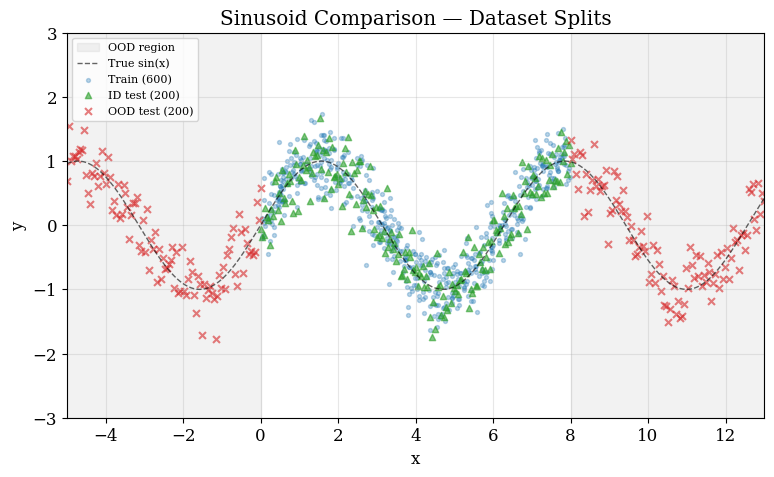

In [7]:
# Dataset visualization: train + ID test + OOD test
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=8, alpha=0.3, label="Train (600)")
ax.scatter(X_test_id.flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=20,
           alpha=0.6, label="ID test (200)")
ax.scatter(X_test_ood.flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=25,
           alpha=0.6, label="OOD test (200)")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Sinusoid Comparison — Dataset Splits")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_comparison_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

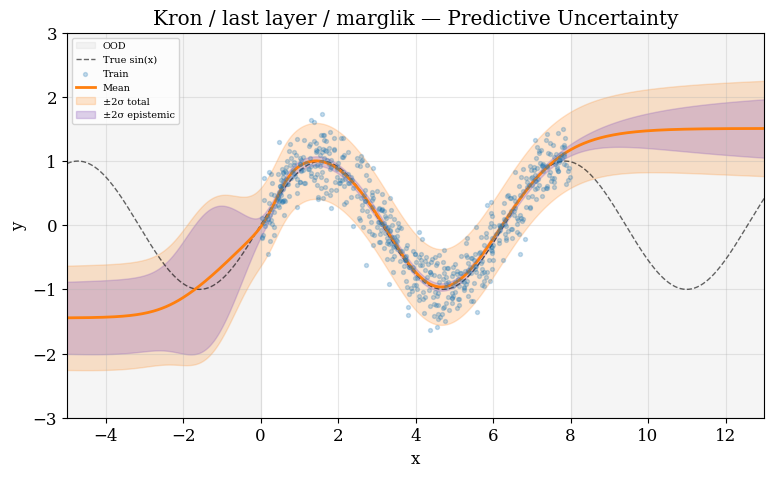

  Saved: sinusoid_comparison_kron_last_layer_marglik_prediction.png


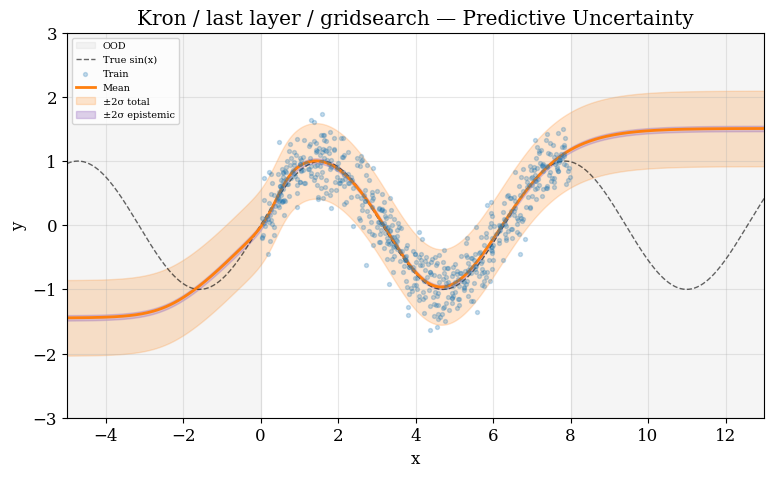

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_prediction.png


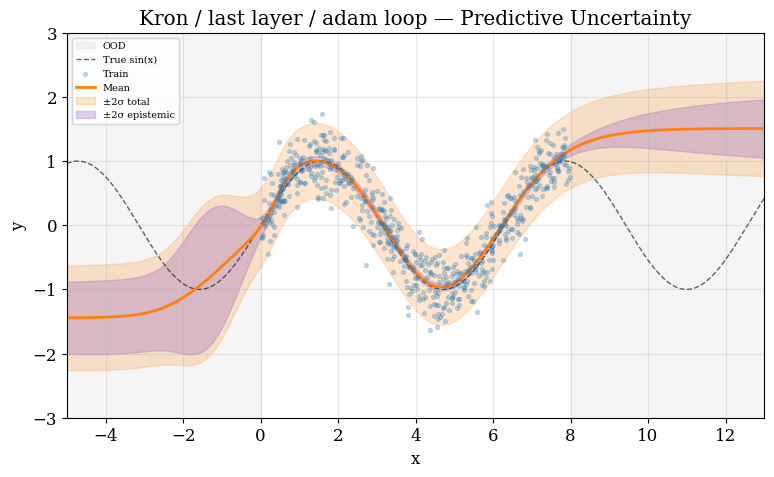

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_prediction.png


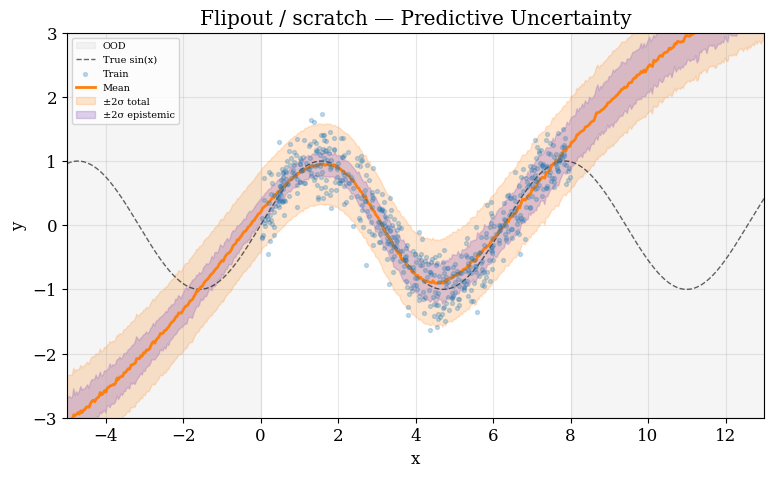

  Saved: sinusoid_comparison_flipout_scratch_prediction.png


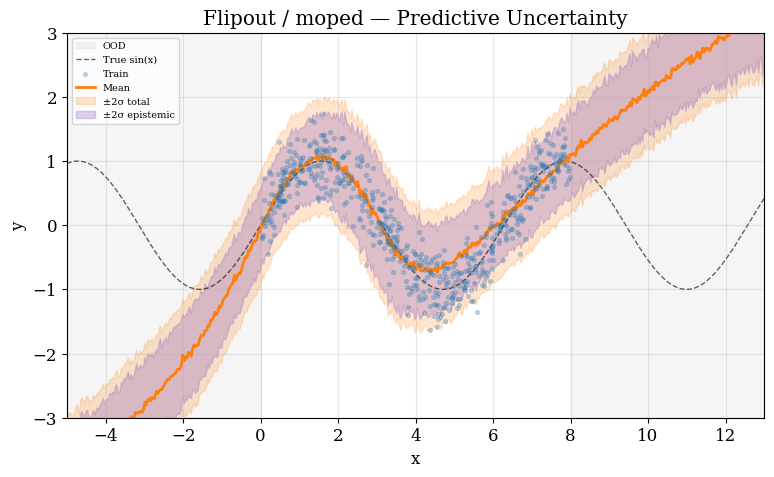

  Saved: sinusoid_comparison_flipout_moped_prediction.png


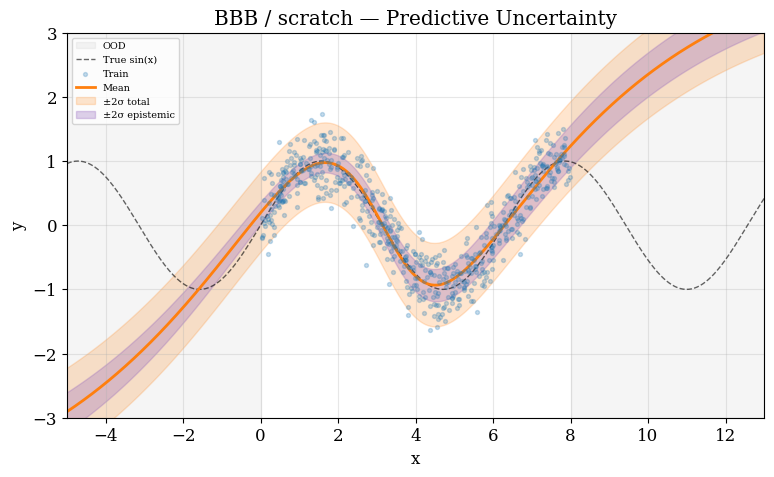

  Saved: sinusoid_comparison_bbb_scratch_prediction.png


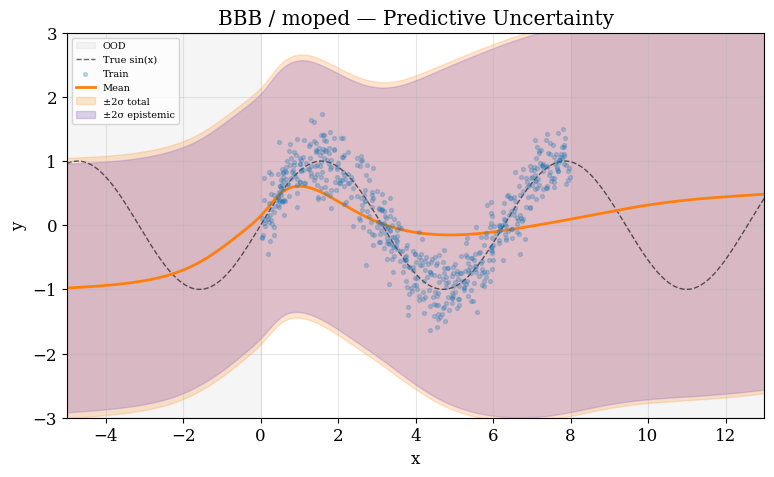

  Saved: sinusoid_comparison_bbb_moped_prediction.png


In [8]:
# Per-variant prediction figures
all_specs_and_results = (
    [(s, la_results[s["variant_name"]], "Laplace") for s in la_variant_specs] +
    [(s, bnn_results[s["variant_name"]], "BNN") for s in bnn_variant_specs]
)
for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    sigma = res.get("sigma", sigma_noise)
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma,
                    f"{title} — Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_prediction.png")

In [9]:
# ID vs OOD scored metrics
ood_rows = []
ood_labels = []

for spec in la_variant_specs:
    vname = spec["variant_name"]
    res = la_results[vname]; sigma = res["sigma"]
    m_id  = regression_metrics(y_test_id_np,  res["mu_id"],  np.sqrt(res["epi_id"]**2  + sigma**2))
    m_ood = regression_metrics(y_test_ood_np, res["mu_ood"], np.sqrt(res["epi_ood"]**2 + sigma**2))
    ood_rows.append({
        "Method": "Laplace",
        "ID NLL": m_id["NLL"],   "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"], "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic":  float(res["epi_id"].mean()),
        "OOD Epistemic": float(res["epi_ood"].mean()),
        "Epistemic Ratio (OOD/ID)": float(res["epi_ood"].mean() / (res["epi_id"].mean() + 1e-12)),
    })
    ood_labels.append(spec["plot_title"])

for spec in bnn_variant_specs:
    vname = spec["variant_name"]
    res = bnn_results[vname]
    m_id  = regression_metrics(y_test_id_np,  res["mu_id"],  np.sqrt(res["epi_id"]**2  + sigma_noise**2))
    m_ood = regression_metrics(y_test_ood_np, res["mu_ood"], np.sqrt(res["epi_ood"]**2 + sigma_noise**2))
    ood_rows.append({
        "Method": "BNN",
        "ID NLL": m_id["NLL"],   "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"], "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic":  float(res["epi_id"].mean()),
        "OOD Epistemic": float(res["epi_ood"].mean()),
        "Epistemic Ratio (OOD/ID)": float(res["epi_ood"].mean() / (res["epi_id"].mean() + 1e-12)),
    })
    ood_labels.append(spec["plot_title"])

ood_df = pd.DataFrame(ood_rows, index=ood_labels)
ood_df.index.name = "Variant"
print("ID vs OOD — higher OOD NLL/RMSE and epistemic ratio > 1 indicates good uncertainty awareness")
display(ood_df.round(4))

ood_df.to_csv("results/metrics/sinusoid_comparison_ood_metrics.csv")
print("\nSaved to results/metrics/sinusoid_comparison_ood_metrics.csv")

ID vs OOD — higher OOD NLL/RMSE and epistemic ratio > 1 indicates good uncertainty awareness


,Method,ID NLL,OOD NLL,ID RMSE,OOD RMSE,ID Coverage_95,OOD Coverage_95,ID Epistemic,OOD Epistemic,Epistemic Ratio (OOD/ID)
Variant,,,,,,,,,,
Kron / last layer / marglik,Laplace,0.2121,9.9704,0.2990,1.6180,0.940,0.315,0.0338,0.2431,7.1879
Kron / last layer / gridsearch,Laplace,0.2119,14.7911,0.2990,1.6180,0.935,0.260,0.0183,0.0213,1.1642
Kron / last layer / adam loop,Laplace,0.2121,9.9640,0.2990,1.6180,0.940,0.315,0.0338,0.2429,7.1782
Flipout / scratch,BNN,0.2539,28.0489,0.3089,2.6539,0.970,0.235,0.1365,0.1678,1.2295
Flipout / moped,BNN,0.4270,17.2479,0.3529,2.7495,0.980,0.250,0.3200,0.3595,1.1234
BBB / scratch,BNN,0.2333,27.7505,0.3043,2.5534,0.955,0.230,0.1069,0.1468,1.3728
BBB / moped,BNN,1.2529,1.5350,0.6042,1.0167,1.000,0.900,1.2216,0.9823,0.8041



Saved to results/metrics/sinusoid_comparison_ood_metrics.csv


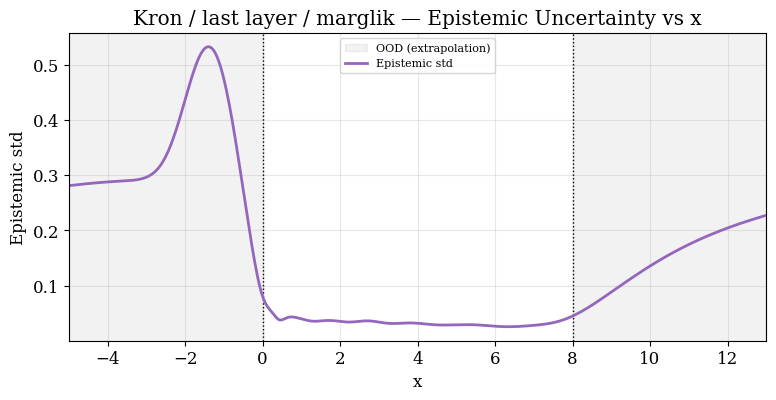

  Saved: sinusoid_comparison_kron_last_layer_marglik_ood_epistemic.png


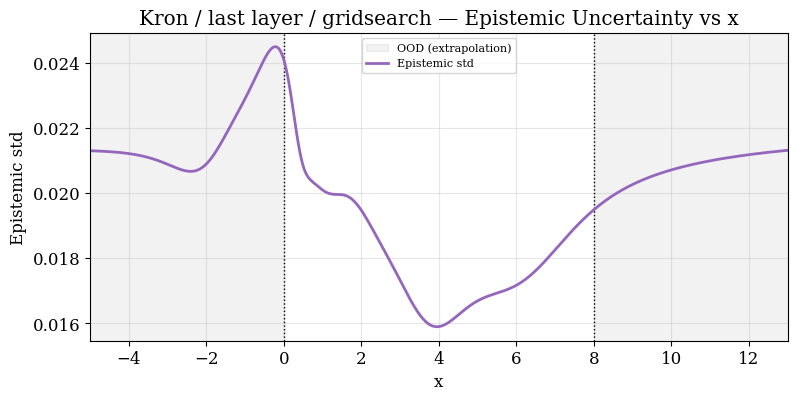

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_ood_epistemic.png


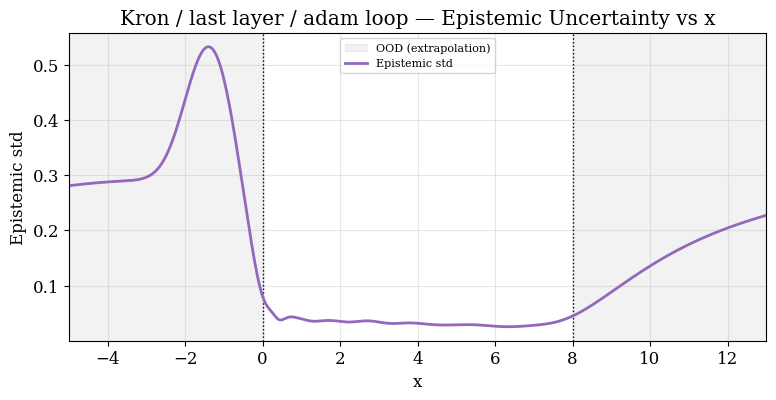

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_ood_epistemic.png


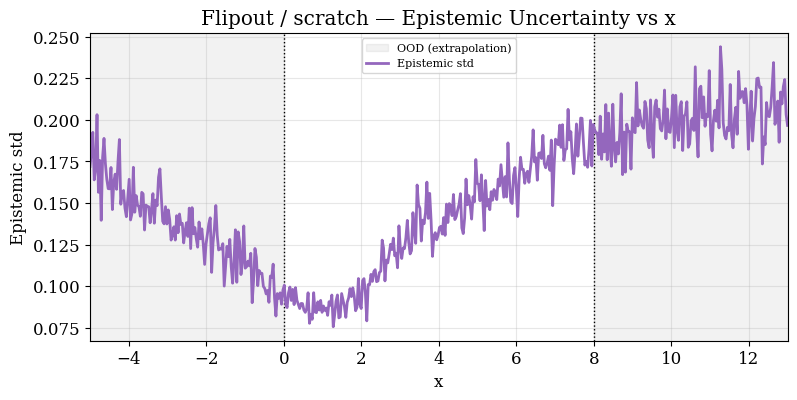

  Saved: sinusoid_comparison_flipout_scratch_ood_epistemic.png


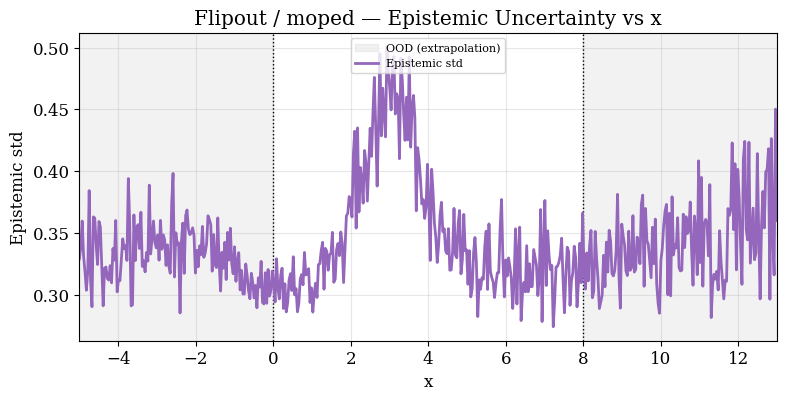

  Saved: sinusoid_comparison_flipout_moped_ood_epistemic.png


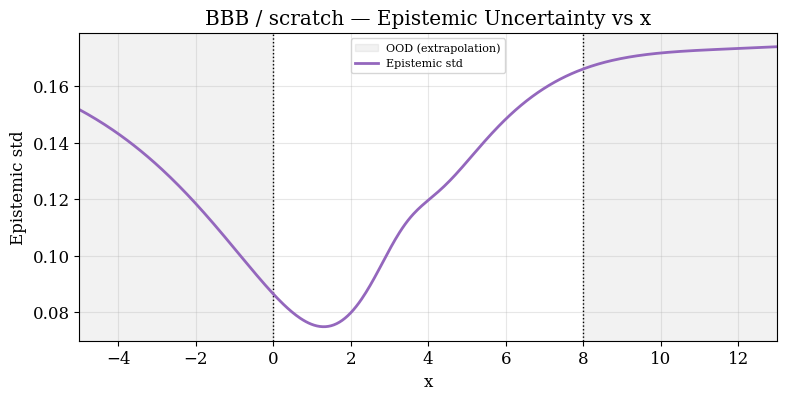

  Saved: sinusoid_comparison_bbb_scratch_ood_epistemic.png


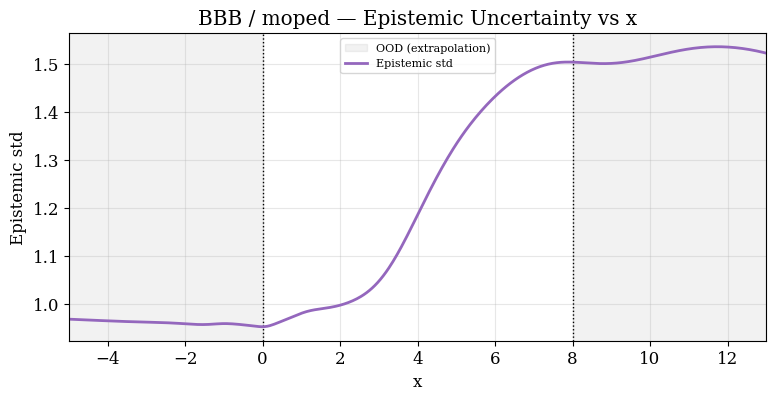

  Saved: sinusoid_comparison_bbb_moped_ood_epistemic.png


In [10]:
# OOD epistemic uncertainty figures
for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    epi = res["epi_std"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi, color="tab:purple", lw=2, label="Epistemic std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} — Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_ood_epistemic.png")

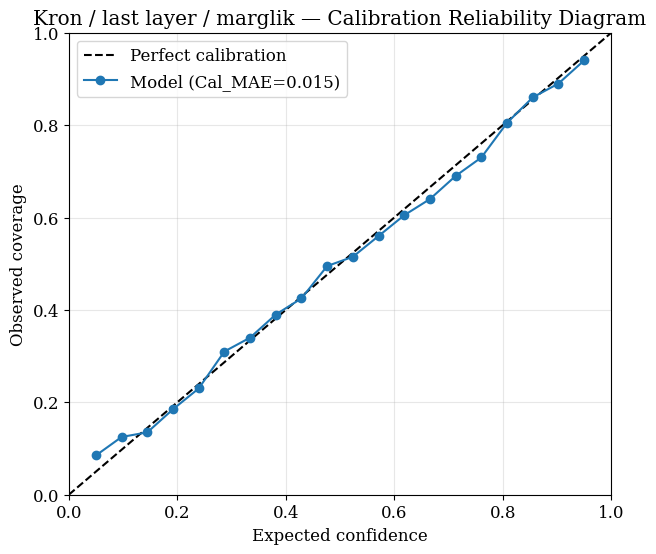

  Saved: sinusoid_comparison_kron_last_layer_marglik_calibration.png


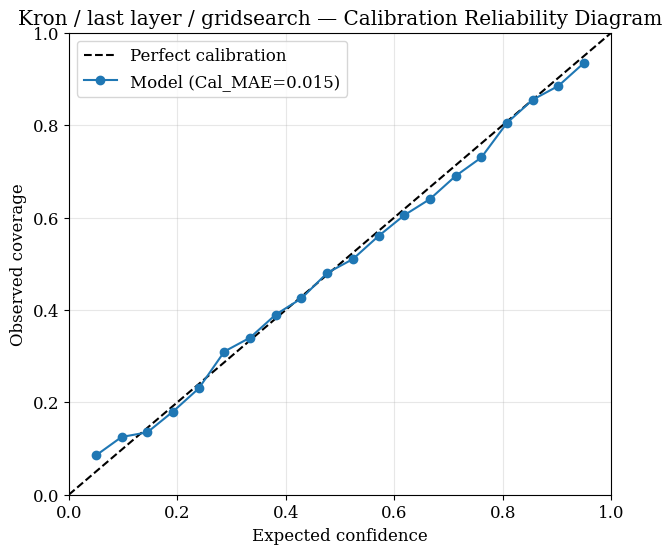

  Saved: sinusoid_comparison_kron_last_layer_gridsearch_calibration.png


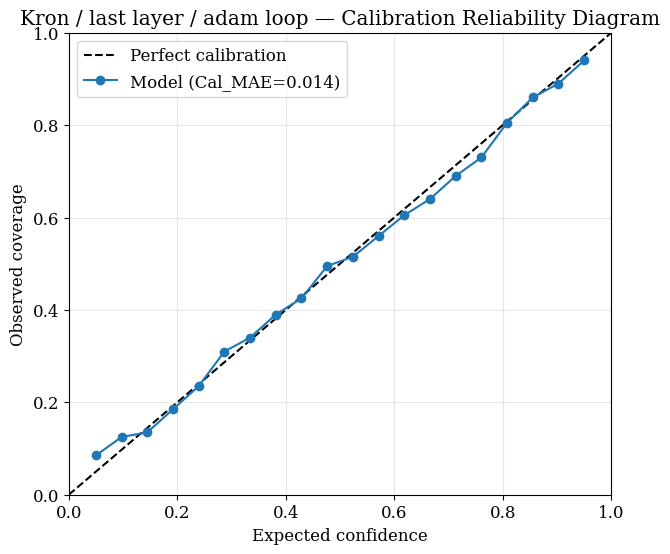

  Saved: sinusoid_comparison_kron_last_layer_adam_loop_calibration.png


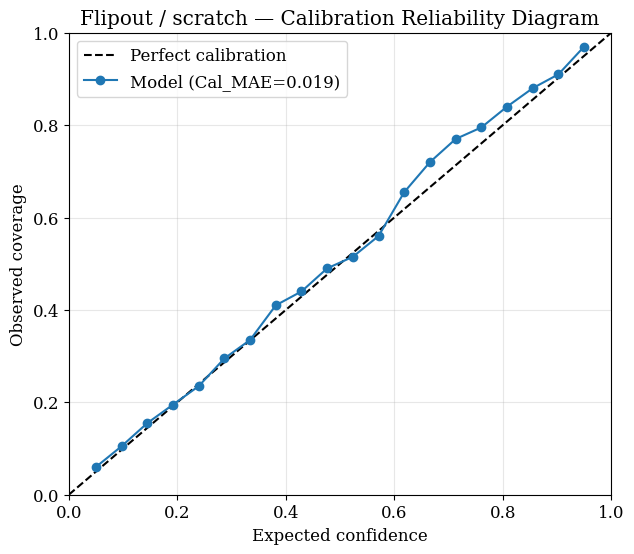

  Saved: sinusoid_comparison_flipout_scratch_calibration.png


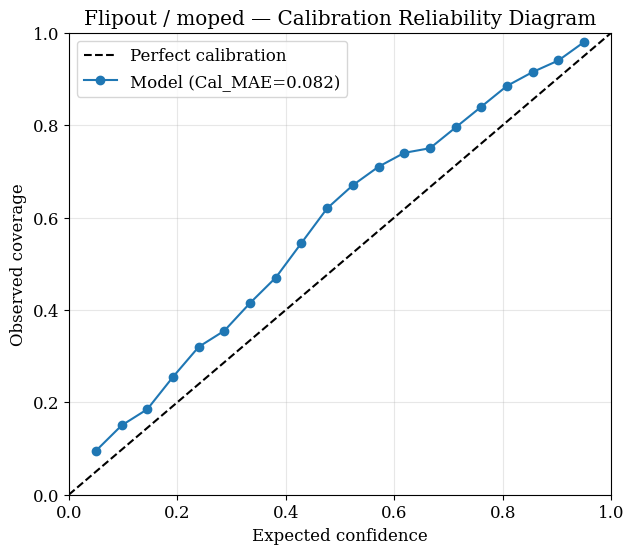

  Saved: sinusoid_comparison_flipout_moped_calibration.png


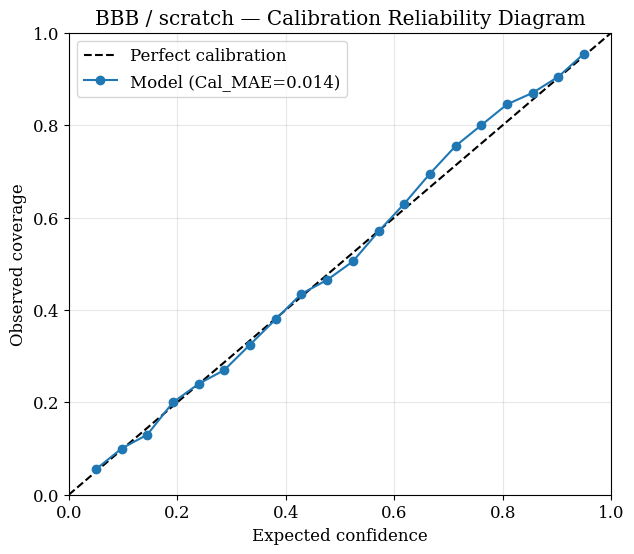

  Saved: sinusoid_comparison_bbb_scratch_calibration.png


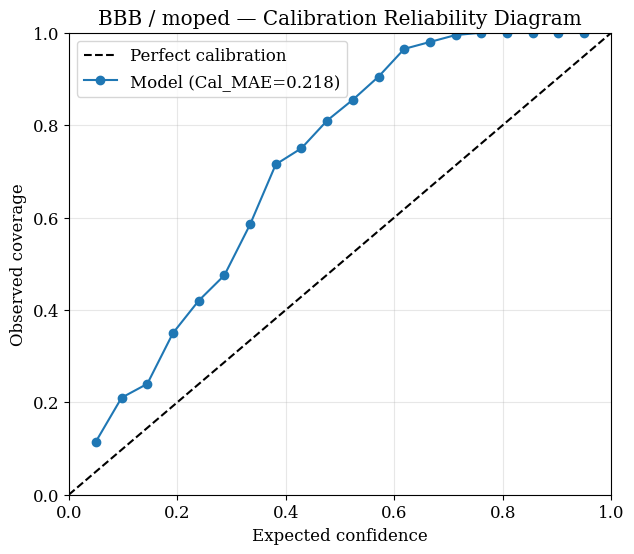

  Saved: sinusoid_comparison_bbb_moped_calibration.png


In [11]:
# Calibration reliability diagrams (ID test set)
conf_levels = np.linspace(0.05, 0.95, 20)

for spec, res, method in all_specs_and_results:
    vname = spec["variant_name"]; title = spec["plot_title"]
    sigma = res.get("sigma", sigma_noise)
    mu_id  = res["mu_id"]
    epi_id = res["epi_id"]
    total_id = np.sqrt(epi_id**2 + sigma**2)
    resid = y_test_id_np - mu_id
    z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
    observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
    cal_mae = float(np.mean(np.abs(observed - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, observed, "o-", label=f"Model (Cal_MAE={cal_mae:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} — Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_comparison_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: sinusoid_comparison_{vname}_calibration.png")